In [16]:
import pandas as pd
import sqlite3
import warnings

warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [17]:
df = pd.read_csv(
    "C:/Users/User/Desktop/E-COMMERCE PERFORMANCE DASHBOARD/data/superstore_clean.csv"
)

print("Dataset loaded successfully!")
print(df.shape)

df.head()

Dataset loaded successfully!
(9994, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [19]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [20]:
# Standardize column names
df.columns = (
    df.columns
    .str.strip()          # Remove extra spaces
    .str.lower()          # Convert to lowercase
    .str.replace(" ", "_") # Replace spaces with underscores
    .str.replace("-", "_") # Replace hyphens with underscores
)

# Display updated column names
print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'year', 'month', 'quarter']


In [21]:
import sqlite3

# Create (or connect to) SQLite database
conn = sqlite3.connect("C:/Users/User/Desktop/E-COMMERCE PERFORMANCE DASHBOARD/data/superstore.db")

print("Database connected successfully!")

Database connected successfully!


In [22]:
df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("Data loaded into SQLite successfully!")

Data loaded into SQLite successfully!


In [23]:
query = "SELECT * FROM sales LIMIT 5;"

preview = pd.read_sql(query, conn)

preview

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub_category,product_name,sales,quantity,discount,profit,year,month,quarter
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16 00:00:00,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4


In [24]:
query = """
SELECT COUNT(*) AS total_records
FROM sales;
"""

pd.read_sql(query, conn)

,total_records
0,9994


In [25]:
conn.close()

print("Database connection closed.")

Database connection closed.


In [26]:
import sqlite3

conn = sqlite3.connect(
    "C:/Users/User/Desktop/E-COMMERCE PERFORMANCE DASHBOARD/data/superstore.db"
)

print("Database connected successfully!")

Database connected successfully!


In [27]:
query = """
SELECT
    product_name,
    ROUND(SUM(sales), 2) AS total_revenue
FROM sales
GROUP BY product_name
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql(query, conn)

top_products

,product_name,total_revenue
0,Canon imageCLASS 2200 Advanced Copier,61599.82
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48
3,HON 5400 Series Task Chairs for Big and Tall,21870.58
4,GBC DocuBind TL300 Electric Binding System,19823.48
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.50
6,Hewlett Packard LaserJet 3310 Copier,18839.69
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.90
8,GBC DocuBind P400 Electric Binding System,17965.07
9,High Speed Automatic Electric Letter Opener,17030.31


### Business Insight

The analysis shows that the Canon imageCLASS 2200 Advanced Copier is the highest revenue-generating product, followed by several office equipment and technology products. These high-performing products contribute significantly to overall sales and should be prioritized for inventory management, marketing campaigns, and customer retention strategies.

In [30]:
query = """
SELECT
    region,
    ROUND(SUM(sales), 2) AS total_sales
FROM sales
GROUP BY region
ORDER BY total_sales DESC;
"""

sales_by_region = pd.read_sql(query, conn)

sales_by_region

,region,total_sales
0,West,725457.82
1,East,678781.24
2,Central,501239.89
3,South,391721.91


### Business Insight

The West region generated the highest total sales, followed closely by the East region. In contrast, the South region recorded the lowest sales performance. The business should continue strengthening its presence in high-performing regions while investigating opportunities to improve sales in the South region through targeted marketing, pricing strategies, or product availability.

In [31]:
query = """
SELECT
    category,
    ROUND(SUM(sales), 2) AS total_sales
FROM sales
GROUP BY category
ORDER BY total_sales DESC;
"""

sales_by_category = pd.read_sql(query, conn)

sales_by_category

,category,total_sales
0,Technology,836154.03
1,Furniture,741999.80
2,Office Supplies,719047.03


### Business Insight

The Technology category generated the highest total sales, making it the strongest-performing product category. Furniture ranked second, while Office Supplies recorded the lowest sales. The business should continue investing in high-performing technology products while exploring opportunities to increase sales in the Office Supplies category through promotions, product expansion, or pricing strategies.

In [32]:
query = """
SELECT
    year,
    month,
    ROUND(SUM(sales), 2) AS monthly_revenue
FROM sales
GROUP BY year, month
ORDER BY year, month;
"""

monthly_revenue = pd.read_sql(query, conn)

monthly_revenue

,year,month,monthly_revenue
0,2014,1,14236.90
1,2014,2,4519.89
2,2014,3,55691.01
3,2014,4,28295.35
4,2014,5,23648.29
5,2014,6,34595.13
6,2014,7,33946.39
7,2014,8,27909.47
8,2014,9,81777.35
9,2014,10,31453.39


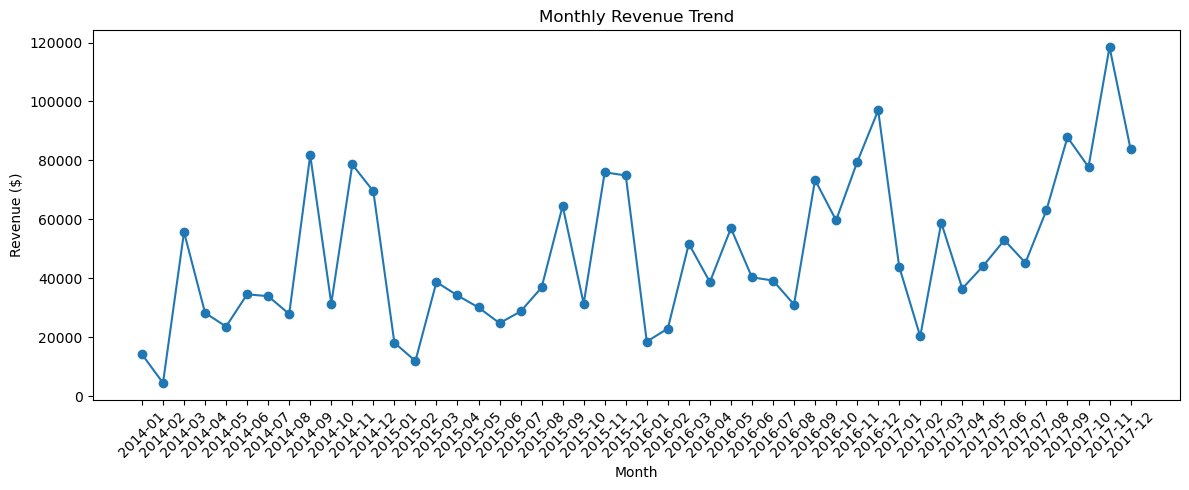

In [33]:
import matplotlib.pyplot as plt

monthly_revenue["period"] = (
    monthly_revenue["year"].astype(str) + "-" +
    monthly_revenue["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue["period"], monthly_revenue["monthly_revenue"], marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()